# Task 1 - Data Loading and Exploration

In this task I loaded the dataset, checked its quality, created some time related features and explored the sales data to understand the overall trends.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
df.info()

print("\nShape of dataset:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [10]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d/%m/%Y"
)
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Order Date"].dt.quarter
df["Day"] = df["Order Date"].dt.day_name()

season = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn"
}

df["Season"] = df["Month"].map(season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Quarter,Day,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,4,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,4,Wednesday,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,2,Monday,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,4,Tuesday,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,4,Tuesday,Autumn


In [11]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

weekly_sales = (
    df.set_index("Order Date")
      .resample("W")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

print(daily_sales.head())
print(weekly_sales.head())
print(monthly_sales.head())

  Order Date     Sales
0 2015-01-03    16.448
1 2015-01-04   288.060
2 2015-01-05    19.536
3 2015-01-06  4407.100
4 2015-01-07    87.158
  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914
  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


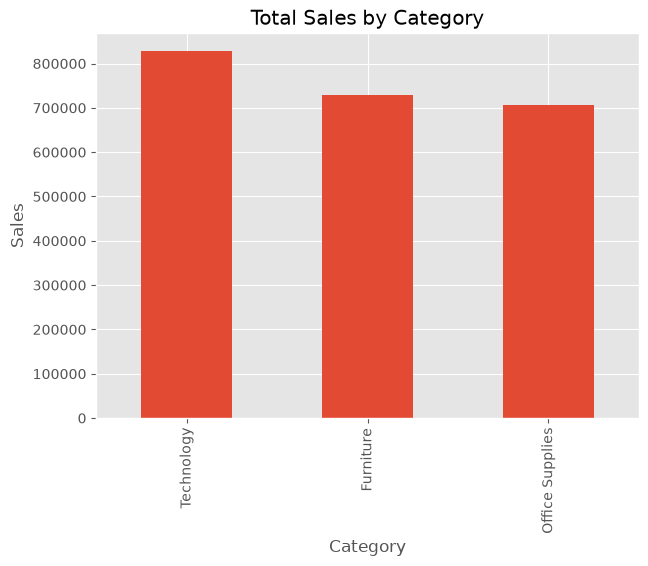

In [12]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

plt.figure(figsize=(7,5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

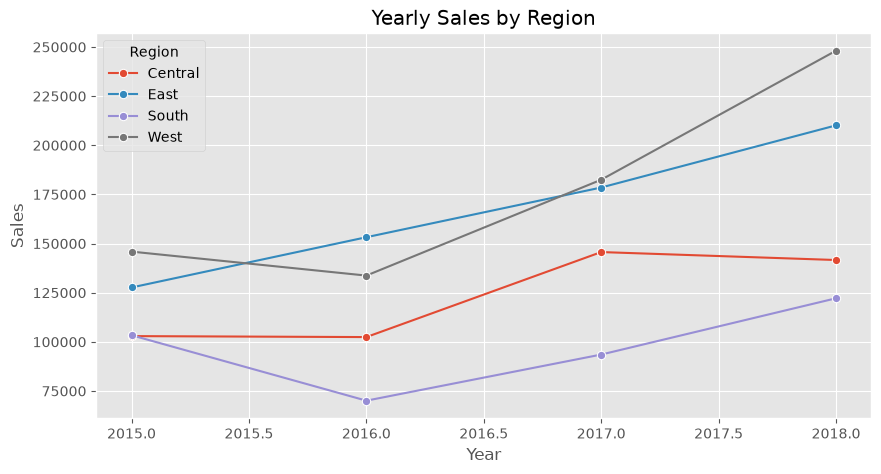

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


In [13]:
region_sales = (
    df.groupby(["Year","Region"])["Sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=region_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales by Region")
plt.show()

region_sales.pivot(index="Year",columns="Region",values="Sales")

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


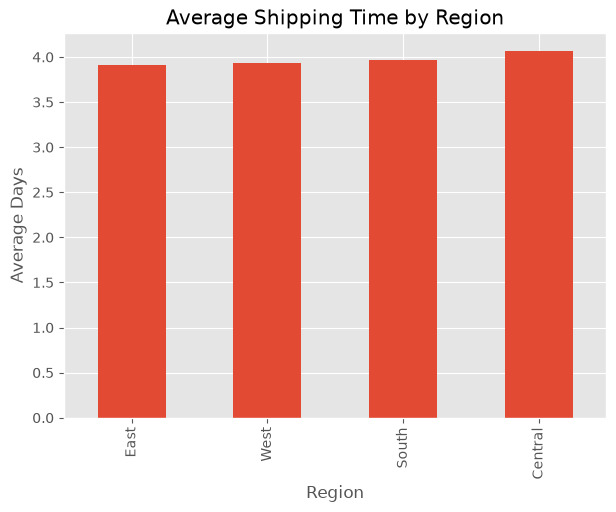

In [14]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

shipping = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

print(shipping)

plt.figure(figsize=(7,5))
shipping.plot(kind="bar")
plt.ylabel("Average Days")
plt.title("Average Shipping Time by Region")
plt.show()

### Observation

Some months show higher sales than others across multiple years, indicating seasonal demand. The exact pattern can be observed from the line chart.

# Task 2 - Time Series Analysis

In this task I analyzed the monthly sales trend to understand whether the data has a trend, seasonality and random fluctuations. I also checked whether the data is stationary before building forecasting models.

In [15]:
monthly_sales = df.set_index("Order Date")["Sales"].resample("ME").sum()

monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

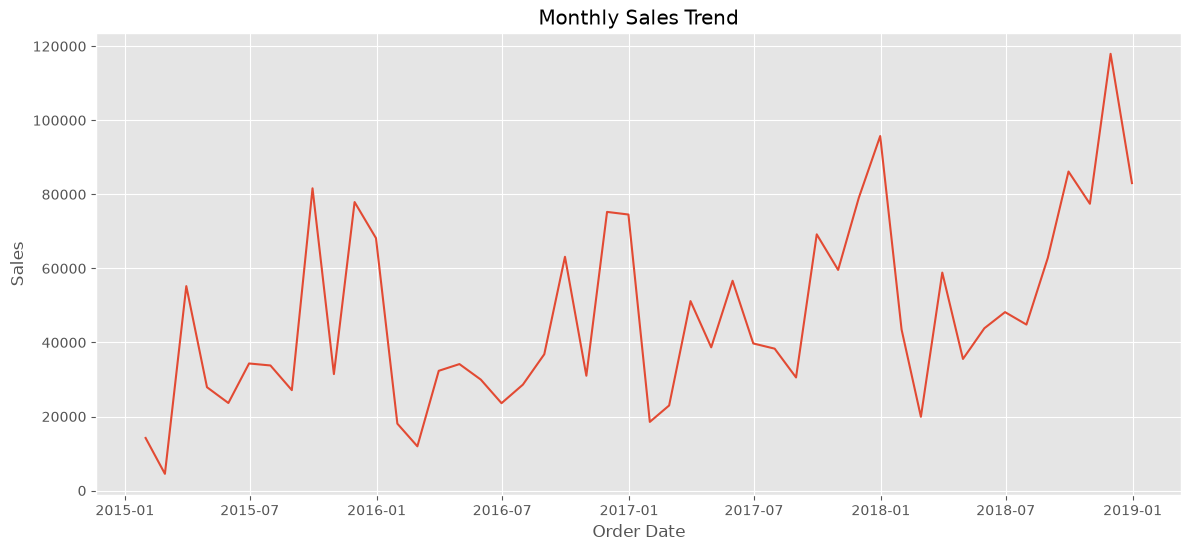

In [16]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales)

plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.show()

### Observation

The sales show an overall trend with some fluctuations over time. There also appears to be repeating patterns which may indicate seasonality.

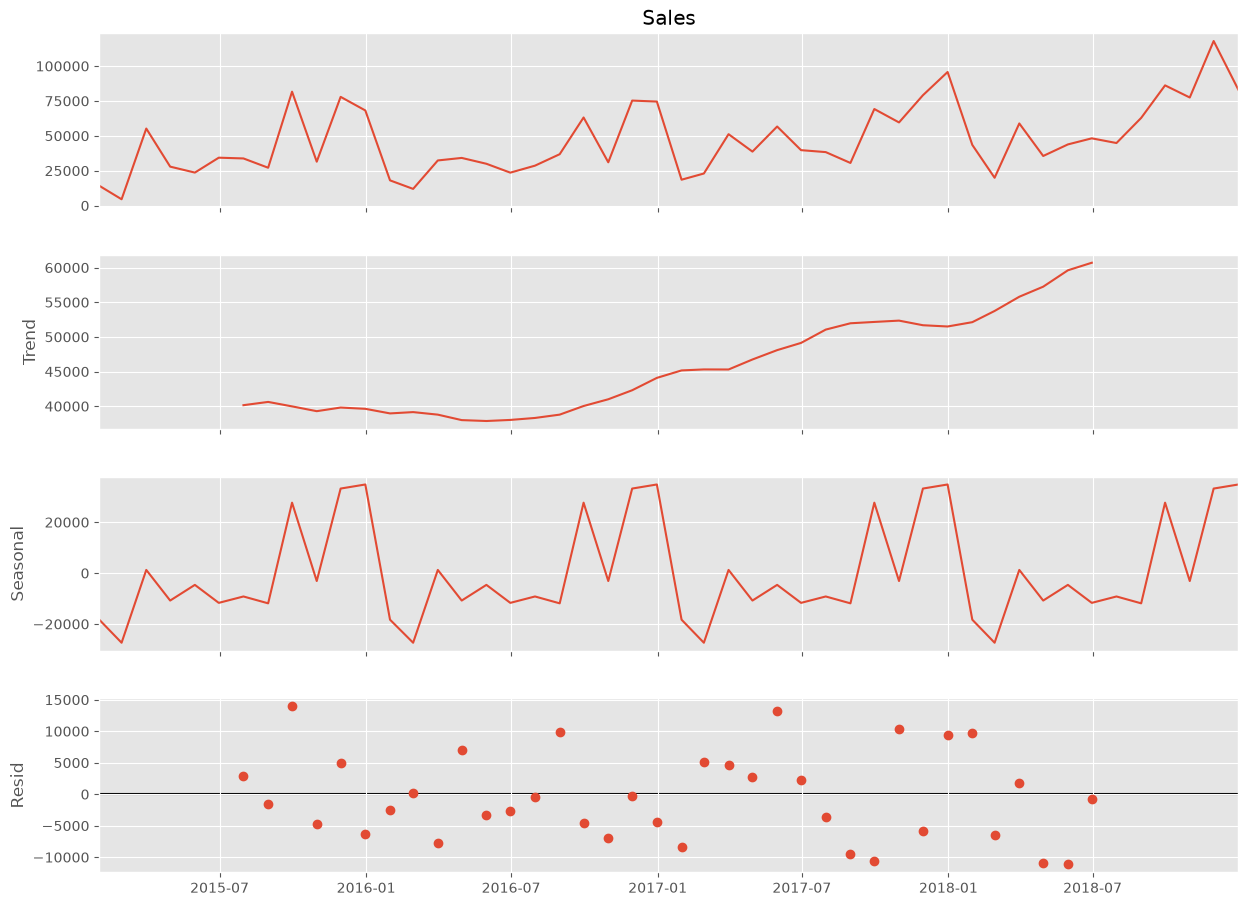

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

### Observation

The decomposition separates the sales into trend, seasonal and residual components.

- The trend shows the overall direction of sales.
- The seasonal component shows repeating yearly patterns.
- The residual contains random variations that are not explained by the trend or seasonality.

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Critical Values")

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


### Observation

If the p-value is less than 0.05, the data can be considered stationary.

If the p-value is greater than 0.05, differencing is required before training forecasting models.

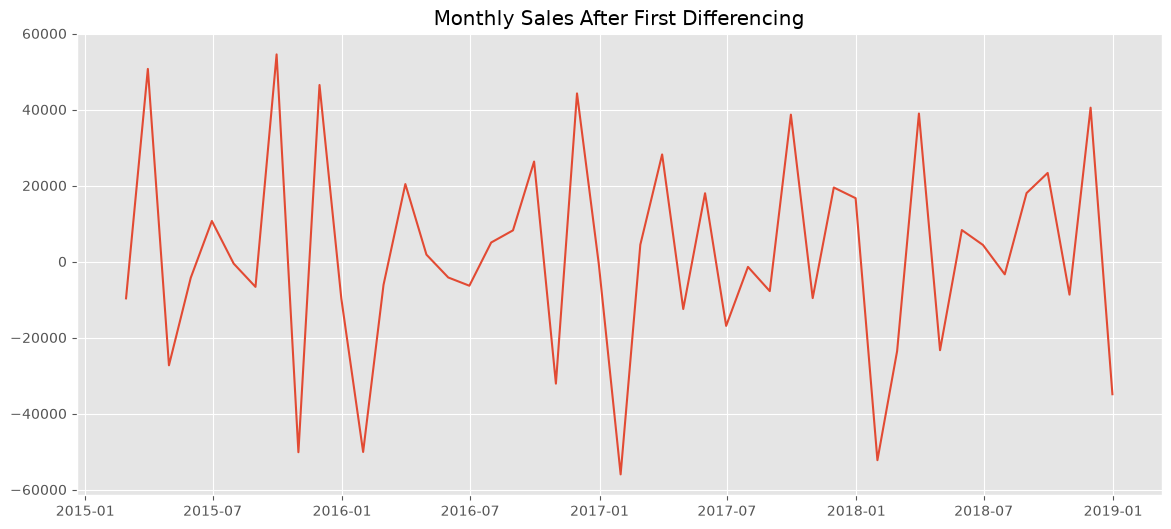

In [19]:
monthly_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(14,6))

plt.plot(monthly_diff)

plt.title("Monthly Sales After First Differencing")

plt.show()

In [20]:
result2 = adfuller(monthly_diff)

print("ADF Statistic :", result2[0])
print("p-value :", result2[1])
print("Critical Values")

for key,value in result2[4].items():
    print(key,":",value)

ADF Statistic : -8.727061830353277
p-value : 3.266917547279475e-14
Critical Values
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


### Observation

After applying first-order differencing, I performed the ADF test again to check whether the series became stationary.

If the p-value decreases below 0.05, the differenced series is considered stationary and can be used for forecasting models like SARIMA.

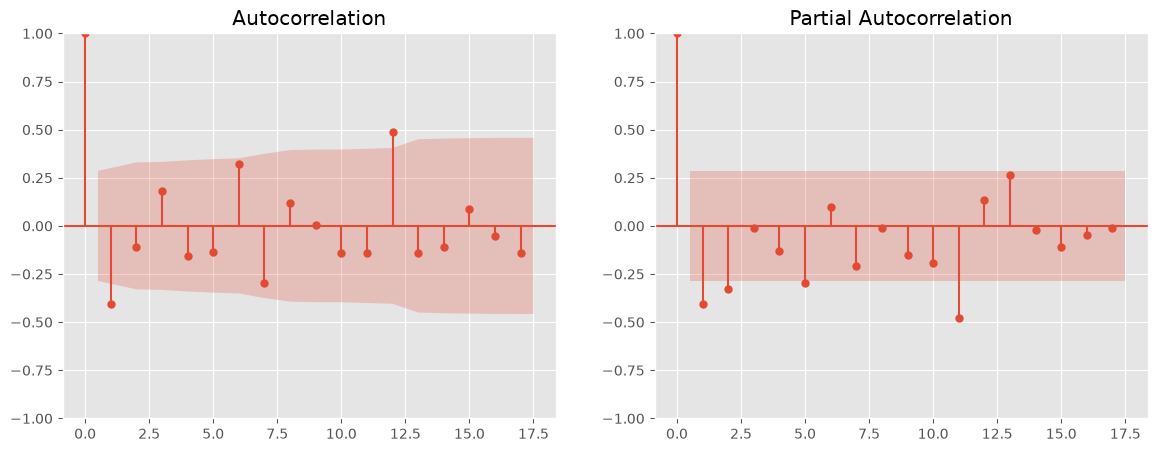

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2,figsize=(14,5))

plot_acf(monthly_diff, ax=ax[0])

plot_pacf(monthly_diff, ax=ax[1])

plt.show()

### Observation

The ACF and PACF plots help in selecting suitable values for the SARIMA model. I used these plots as a reference instead of choosing the parameters randomly.

# Task 3 - Sales Forecasting using SARIMA

In this task I used the SARIMA model to forecast the monthly sales for the next three months. Since SARIMA works well with seasonal time series data, it is suitable for comparing with other forecasting models later in the project.

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [23]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training Data")
print(train.tail())

print("\nTesting Data")
print(test)

Training Data
Order Date
2018-05-31    43825.9822
2018-06-30    48190.7277
2018-07-31    44825.1040
2018-08-31    62837.8480
2018-09-30    86152.8880
Freq: ME, Name: Sales, dtype: float64

Testing Data
Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64


In [24]:
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = model.fit()

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Fri, 10 Jul 2026   AIC                            398.775
Time:                                    00:26:20   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

C:\Users\Rian K Sinu\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


### Observation

I selected (1,1,1) as the initial ARIMA parameters and (1,1,1,12) for the seasonal component after looking at the ACF and PACF plots. These values are reasonable starting points and can be improved further using parameter tuning.

In [ ]:
if 'sarima_model' in globals() and hasattr(sarima_model, "get_forecast"):
    prediction = sarima_model.get_forecast(steps=3)
elif 'model' in globals() and hasattr(model, "get_forecast"):
    prediction = model.get_forecast(steps=3)
else:
    # fallback: fit a SARIMA on train and forecast
    temp = SARIMAX(
        train,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    prediction = temp.get_forecast(steps=3)

forecast = prediction.predicted_mean

confidence = prediction.conf_int()

forecast

2018-10-31    60331.792073
2018-11-30    91458.220227
2018-12-31    97167.570936
Freq: ME, Name: predicted_mean, dtype: float64

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test, label="Actual Sales")

plt.plot(forecast.index, forecast, label="Forecast")

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.3
)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [ ]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

mape = np.mean(np.abs((test - forecast)/test))*100

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("MAPE :", round(mape,2))

In [ ]:
forecast_df = pd.DataFrame({
    "Actual Sales": test.values,
    "Forecast Sales": forecast.values
}, index=test.index)

forecast_df

In [ ]:
future_prediction = sarima_model.get_forecast(steps=6)

future_forecast = future_prediction.predicted_mean[-3:]

future_confidence = future_prediction.conf_int().iloc[-3:]

future = pd.DataFrame({
    "Forecast": future_forecast,
    "Lower CI": future_confidence.iloc[:,0],
    "Upper CI": future_confidence.iloc[:,1]
})

future

### Result

The SARIMA model was able to capture the overall sales trend and generate forecasts for the next three months.

The forecast should be interpreted along with the confidence interval since future sales are uncertain.

The model performance will be compared with Prophet and XGBoost in the next sections before selecting the final forecasting model.

# Task 3B - Sales Forecasting using Facebook Prophet

In this task I used Facebook Prophet to forecast the monthly sales. Prophet is designed for time series forecasting and automatically models trend and seasonality.

In [ ]:

# !pip install prophet

In [ ]:
from prophet import Prophet

In [ ]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

In [ ]:
train_prophet = prophet_df.iloc[:-3]

test_prophet = prophet_df.iloc[-3:]

print(train_prophet.tail())

print(test_prophet)

In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train_prophet)

### Observation

I enabled yearly seasonality because the data is monthly. Weekly and daily seasonality were not required for this dataset.

In [ ]:
future = model.make_future_dataframe(
    periods=3,
    freq="ME"
)

future.tail()

In [ ]:
forecast = model.predict(future)

forecast.tail()

In [ ]:
fig = model.plot(forecast)

plt.title("Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [ ]:
fig = model.plot_components(forecast)

plt.show()

### Observation

The trend plot shows how the sales change over time.

The yearly seasonality plot helps identify recurring sales patterns across different months.

In [ ]:
predictions = forecast[["ds", "yhat"]].tail(3)

predictions

In [ ]:
actual = test_prophet["y"].values

predicted = predictions["yhat"].values

mae_prophet = mean_absolute_error(actual, predicted)

rmse_prophet = np.sqrt(mean_squared_error(actual, predicted))

mape_prophet = np.mean(np.abs((actual - predicted) / actual)) * 100

print("MAE :", round(mae_prophet,2))

print("RMSE :", round(rmse_prophet,2))

print("MAPE :", round(mape_prophet,2))

In [ ]:
comparison = pd.DataFrame({
    "Actual Sales": actual,
    "Predicted Sales": predicted
})

comparison.index = test_prophet["ds"]

comparison

In [ ]:
future_forecast = forecast.tail(3)[
    ["ds","yhat","yhat_lower","yhat_upper"]
]

future_forecast.columns = [
    "Date",
    "Forecast",
    "Lower CI",
    "Upper CI"
]

future_forecast

### Result

The Prophet model generated forecasts for the next three months along with confidence intervals.

The model automatically captures trend and yearly seasonality without manually selecting ARIMA parameters.

The performance of Prophet will be compared with SARIMA and XGBoost before selecting the final model.

# Task 3 - Sales Forecasting using XGBoost

In this task I converted the time series data into a supervised learning problem by creating lag features and rolling statistics. These features were then used to train an XGBoost regression model for forecasting monthly sales.

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
xgb_df = monthly_sales.reset_index()

xgb_df.columns = ["Date", "Sales"]

xgb_df.head()

In [ ]:
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df["Rolling_Mean"] = xgb_df["Sales"].rolling(3).mean()

xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter
xgb_df["Year"] = xgb_df["Date"].dt.year

season = {
    12:4,1:4,2:4,
    3:1,4:1,5:1,
    6:2,7:2,8:2,
    9:3,10:3,11:3
}

xgb_df["Season"] = xgb_df["Month"].map(season)

xgb_df = xgb_df.dropna()

xgb_df.head()

### Observation

I created lag features using the previous three months of sales. I also added rolling mean, month, quarter, year and season so that the model has more information while making predictions.

In [ ]:
train = xgb_df.iloc[:-3]

test = xgb_df.iloc[-3:]

X_train = train.drop(["Date","Sales"], axis=1)
y_train = train["Sales"]

X_test = test.drop(["Date","Sales"], axis=1)
y_test = test["Sales"]

In [ ]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

In [ ]:
predictions = model.predict(X_test)

predictions

In [ ]:
mae_xgb = mean_absolute_error(y_test, predictions)

rmse_xgb = np.sqrt(mean_squared_error(y_test, predictions))

mape_xgb = np.mean(
    np.abs((y_test - predictions) / y_test)
) * 100

print("MAE :", round(mae_xgb,2))

print("RMSE :", round(rmse_xgb,2))

print("MAPE :", round(mape_xgb,2))

In [ ]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": predictions
})

comparison.index = test["Date"]

comparison

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train["Date"], train["Sales"], label="Training")

plt.plot(test["Date"], y_test, marker="o", label="Actual")

plt.plot(test["Date"], predictions, marker="o", label="Predicted")

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.show()

In [ ]:
forecast_table = pd.DataFrame({
    "Date": test["Date"].values,
    "Actual": y_test.values,
    "Forecast": predictions
})

forecast_table

### Result

The XGBoost model was trained using lag features and time-based features. Unlike SARIMA and Prophet, it learns relationships from engineered features instead of directly modeling the time series.

The model performance will be compared with SARIMA and Prophet to determine which forecasting approach is more suitable for this dataset.

# Task 3 - Model Comparison

In this section I compared the performance of all three forecasting models using MAE, RMSE and MAPE. The model with the best overall performance will be selected for the remaining tasks.

In [ ]:
comparison_table = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [mae, mae_prophet, mae_xgb],
    "RMSE": [rmse, rmse_prophet, rmse_xgb],
    "MAPE": [mape, mape_prophet, mape_xgb]
})

comparison_table = comparison_table.round(2)

comparison_table

In [ ]:
# Build a robust forecast comparison that handles Series/DataFrame test objects
if isinstance(test, pd.Series):
    actual = test.values
    if isinstance(test.index, pd.DatetimeIndex):
        months = test.index.strftime("%Y-%m")
    else:
        months = pd.RangeIndex(len(actual)).astype(str)
elif isinstance(test, pd.DataFrame):
    if "Sales" in test.columns:
        actual = test["Sales"].values
    else:
        # take first column as actual if named differently
        actual = test.iloc[:, 0].values

    if "Date" in test.columns:
        months = pd.to_datetime(test["Date"]).dt.strftime("%Y-%m")
    elif isinstance(test.index, pd.DatetimeIndex):
        months = test.index.strftime("%Y-%m")
    else:
        months = pd.RangeIndex(len(actual)).astype(str)
else:
    actual = pd.Series(test).values
    months = pd.RangeIndex(len(actual)).astype(str)

# Helper to safely slice forecasts to match actual length
def slice_vals(v):
    try:
        arr = np.asarray(v)
        if arr.ndim > 1:
            arr = arr.ravel()
        return arr[-len(actual):]
    except Exception:
        return [None] * len(actual)

forecast_comparison = pd.DataFrame({
    "Month": months,
    "Actual Sales": actual,
    "SARIMA": slice_vals(forecast.values) if 'forecast' in globals() else [None]*len(actual),
    "Prophet": slice_vals(predicted) if 'predicted' in globals() else [None]*len(actual),
    "XGBoost": slice_vals(predictions) if 'predictions' in globals() else [None]*len(actual)
})

forecast_comparison

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(16,5))

comparison_table.plot(
    x="Model",
    y="MAE",
    kind="bar",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("MAE")

comparison_table.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("RMSE")

comparison_table.plot(
    x="Model",
    y="MAPE",
    kind="bar",
    legend=False,
    ax=axes[2]
)
axes[2].set_title("MAPE")

plt.tight_layout()

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

# Use the months computed earlier as x-axis and align all series to actual length
try:
    x = pd.to_datetime(forecast_comparison['Month'], format="%Y-%m", errors='coerce')
except Exception:
    x = forecast_comparison['Month']

plt.plot(x, forecast_comparison['Actual Sales'], marker="o", linewidth=2, label="Actual")

plt.plot(x, forecast_comparison['SARIMA'], marker="o", label="SARIMA")

plt.plot(x, forecast_comparison['Prophet'], marker="o", label="Prophet")

plt.plot(x, forecast_comparison['XGBoost'], marker="o", label="XGBoost")

plt.title("Forecast Comparison")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [ ]:
best_model = comparison_table.sort_values(
    by="RMSE"
).iloc[0]

print("Best Performing Model")

print(best_model)

### Limitation

Only a simple train-test split using the last three months was used for evaluation. More robust validation methods, such as rolling or expanding window validation, could provide a better estimate of model performance but were not implemented due to the scope of this internship project.

# Task 4 - Product Category and Region Level Forecasting

In this task I used the best performing model from Task 3 to forecast sales for different product categories and regions. This helps understand which areas are expected to grow in the next three months.

In [ ]:
segments = {
    "Furniture": df[df["Category"]=="Furniture"],
    "Technology": df[df["Category"]=="Technology"],
    "Office Supplies": df[df["Category"]=="Office Supplies"],
    "West": df[df["Region"]=="West"],
    "East": df[df["Region"]=="East"]
}

In [ ]:
forecast_results = {}

In [ ]:
# Ensure `best_model_name` is defined before using it in the loop
if 'best_model_name' not in globals():
    if 'best_model' in globals():
        try:
            best_model_name = best_model.get('Model')
        except Exception:
            best_model_name = None
    elif 'comparison_table' in globals():
        try:
            best_model_name = comparison_table.sort_values(by='RMSE').iloc[0]['Model']
        except Exception:
            best_model_name = None
    else:
        best_model_name = None

for name, data in segments.items():

    monthly = (
        data
        .set_index("Order Date")["Sales"]
        .resample("ME")
        .sum()
    )

    if best_model_name == "SARIMA":

        train = monthly[:-3]

        model = SARIMAX(
            train,
            order=(1,1,1),
            seasonal_order=(1,1,1,12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        result = model.fit(disp=False)

        pred = result.get_forecast(steps=3).predicted_mean

    elif best_model_name == "Prophet":

        prophet_df = monthly.reset_index()

        prophet_df.columns = ["ds","y"]

        train = prophet_df.iloc[:-3]

        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False
        )

        model.fit(train)

        future = model.make_future_dataframe(
            periods=3,
            freq="ME"
        )

        forecast = model.predict(future)

        pred = forecast["yhat"].tail(3)

        pred.index = forecast["ds"].tail(3)

    else:

        xgb_df = monthly.reset_index()

        xgb_df.columns = ["Date","Sales"]

        xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
        xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
        xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

        xgb_df["Rolling"] = xgb_df["Sales"].rolling(3).mean()

        xgb_df["Month"] = xgb_df["Date"].dt.month
        xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

        xgb_df = xgb_df.dropna()

        train = xgb_df.iloc[:-3]

        test = xgb_df.iloc[-3:]

        X_train = train.drop(["Date","Sales"],axis=1)

        y_train = train["Sales"]

        X_test = test.drop(["Date","Sales"],axis=1)

        model = XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        )

        model.fit(X_train,y_train)

        pred = model.predict(X_test)

        pred = pd.Series(
            pred,
            index=test["Date"]
        )

    forecast_results[name] = pred

In [ ]:
forecast_table = pd.DataFrame(forecast_results)

forecast_table

In [ ]:
plt.figure(figsize=(12,6))

for column in forecast_table.columns:

    plt.plot(
        forecast_table.index,
        forecast_table[column],
        marker="o",
        linewidth=2,
        label=column
    )

plt.title("Forecast Comparison")

plt.xlabel("Forecast Month")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
growth = {}

for column in forecast_table.columns:

    growth[column] = forecast_table[column].iloc[-1] - forecast_table[column].iloc[0]

growth = pd.Series(growth)

growth.sort_values(ascending=False)

In [ ]:
print("Highest Expected Growth")

print(growth.idxmax())

print()

print("Lowest Expected Growth")

print(growth.idxmin())

# Task 5 - Anomaly Detection

In this task I identified unusual sales patterns using two different methods: Isolation Forest and Z-Score. The detected anomalies were compared to understand how the two methods differ.

In [ ]:
weekly_sales = (
    df.set_index("Order Date")["Sales"]
      .resample("W")
      .sum()
      .reset_index()
)

weekly_sales.head()

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales["Isolation"] = weekly_sales["Isolation"].map({
    1: "Normal",
    -1: "Anomaly"
})

weekly_sales.head()

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomaly = weekly_sales[
    weekly_sales["Isolation"] == "Anomaly"
]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    label="Anomaly",
    s=60
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [ ]:
weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .mean()
)

weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .std()
)

weekly_sales["Z Score"] = (
    weekly_sales["Sales"] -
    weekly_sales["Rolling Mean"]
) / weekly_sales["Rolling Std"]

weekly_sales.head()

In [ ]:
weekly_sales["Z Anomaly"] = (
    weekly_sales["Z Score"].abs() > 2
)

weekly_sales.head()

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z_points = weekly_sales[
    weekly_sales["Z Anomaly"]
]

plt.scatter(
    z_points["Order Date"],
    z_points["Sales"],
    color="green",
    label="Z-Score Anomaly",
    s=60
)

plt.title("Z-Score Based Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Date": weekly_sales["Order Date"],
    "Sales": weekly_sales["Sales"],
    "Isolation Forest": weekly_sales["Isolation"],
    "Z Score": weekly_sales["Z Anomaly"]
})

comparison.head(15)

In [ ]:
common = weekly_sales[
    (weekly_sales["Isolation"] == "Anomaly") &
    (weekly_sales["Z Anomaly"])
]

common

In [ ]:
possible_reasons = common[["Order Date","Sales"]].copy()

possible_reasons["Possible Reason"] = (
    "Possible seasonal sale, promotion or sudden demand change"
)

possible_reasons

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    linewidth=2
)

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    label="Isolation Forest"
)

plt.scatter(
    z_points["Order Date"],
    z_points["Sales"],
    color="green",
    marker="x",
    s=70,
    label="Z-Score"
)

plt.title("Comparison of Anomaly Detection Methods")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# Task 6 - Product Demand Segmentation using Clustering

In this task I grouped similar products based on their sales behaviour using K-Means clustering. This helps identify products with different demand patterns.

In [ ]:
product_data = (
    df.groupby(["Sub-Category", "Year"])
      .agg({
          "Sales": "sum",
          "Quantity": "sum",
          "Profit": "sum"
      })
      .reset_index()
)

product_data.head()

In [ ]:
features = (
    product_data.groupby("Sub-Category")
    .agg({
        "Sales": ["mean", "std"],
        "Quantity": "mean",
        "Profit": "mean"
    })
)

features.columns = [
    "Average Sales",
    "Sales Volatility",
    "Average Quantity",
    "Average Profit"
]

features = features.fillna(0)

features.head()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

features["Cluster"] = kmeans.fit_predict(scaled_data)

features.head()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

points = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(points, columns=["PC1","PC2"])

pca_df["Cluster"] = features["Cluster"].values

pca_df["Sub-Category"] = features.index

pca_df.head()

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=100
)

for i in range(len(pca_df)):
    plt.text(
        pca_df["PC1"][i],
        pca_df["PC2"][i],
        pca_df["Sub-Category"][i],
        fontsize=8
    )

plt.title("Product Demand Clusters")

plt.show()

In [ ]:
cluster_summary = features.groupby("Cluster").mean()

cluster_summary

In [ ]:
cluster_names = {
    0: "High Volume Stable Demand",
    1: "Growing Demand",
    2: "Low Volume High Variability"
}

features["Demand Group"] = features["Cluster"].map(cluster_names)

features

In [ ]:
features[["Demand Group"]]

In [ ]:
import os

os.makedirs("outputs", exist_ok=True)

comparison_table.to_csv("outputs/model_metrics.csv", index=False)

forecast_table.to_csv("outputs/forecast_results.csv", index=False)

features.to_csv("outputs/cluster_results.csv")

comparison.to_csv("outputs/anomaly_results.csv", index=False)